# Bank Marketing Term Deposit Prediction

**Goal:** Predict whether a bank client will subscribe to a term deposit based on demographic, campaign, and economic data, and identify what actually drives subscription so the marketing team can target better.

**Dataset:** `bank.csv` — 4,119 clients contacted during a Portuguese bank's direct marketing campaign (phone calls), 21 features including demographics, campaign contact history, and macroeconomic indicators. [UCI Bank Marketing Dataset]

**Key finding up front:** An early version of this model hit 100% accuracy — a red flag, not a win. Section 4 walks through diagnosing and fixing that, and section 5 shows the honest, deployable results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data/bank.csv')
print(df.shape)
df.head()

(4119, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


## 1. Exploratory Data Analysis

Quick look at the target variable and a few of the most business-relevant features.

y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


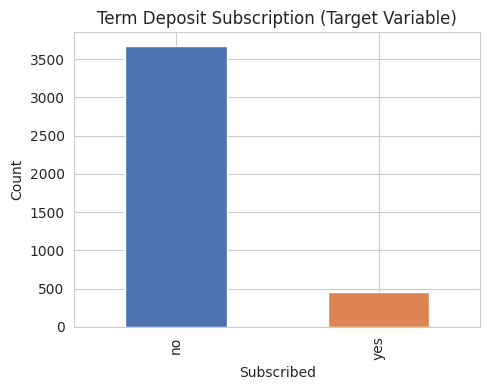

In [2]:
# Target distribution — this is an imbalanced classification problem
subscribe_rate = df['y'].value_counts(normalize=True) * 100
print(subscribe_rate)

fig, ax = plt.subplots(figsize=(5,4))
df['y'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452'])
ax.set_title('Term Deposit Subscription (Target Variable)')
ax.set_xlabel('Subscribed')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/target_distribution.png')
plt.show()

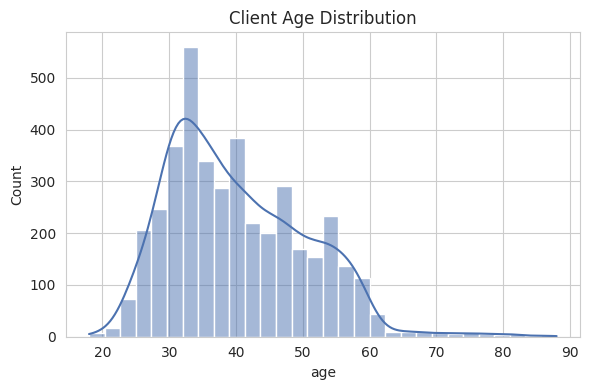

count    4119.000000
mean       40.113620
std        10.313362
min        18.000000
25%        32.000000
50%        38.000000
75%        47.000000
max        88.000000
Name: age, dtype: float64


In [3]:
# Age distribution
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True, ax=ax, color='#4C72B0')
ax.set_title('Client Age Distribution')
plt.tight_layout()
plt.savefig('outputs/age_distribution.png')
plt.show()
print(df['age'].describe())

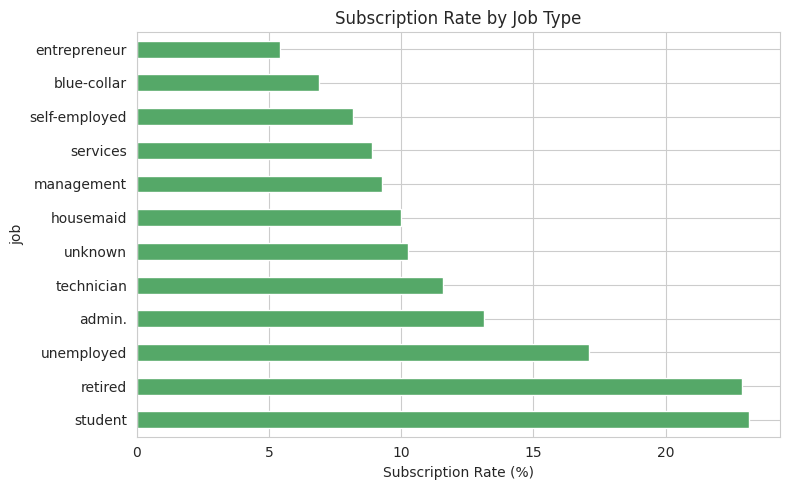

job
student          23.170732
retired          22.891566
unemployed       17.117117
admin.           13.142292
technician       11.577424
unknown          10.256410
housemaid        10.000000
management        9.259259
services          8.905852
self-employed     8.176101
blue-collar       6.900452
entrepreneur      5.405405
Name: y, dtype: float64

In [4]:
# Subscription rate by job
job_rate = df.groupby('job')['y'].apply(lambda x: (x=='yes').mean()*100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,5))
job_rate.plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Subscription Rate (%)')
ax.set_title('Subscription Rate by Job Type')
plt.tight_layout()
plt.savefig('outputs/subscription_by_job.png')
plt.show()
job_rate

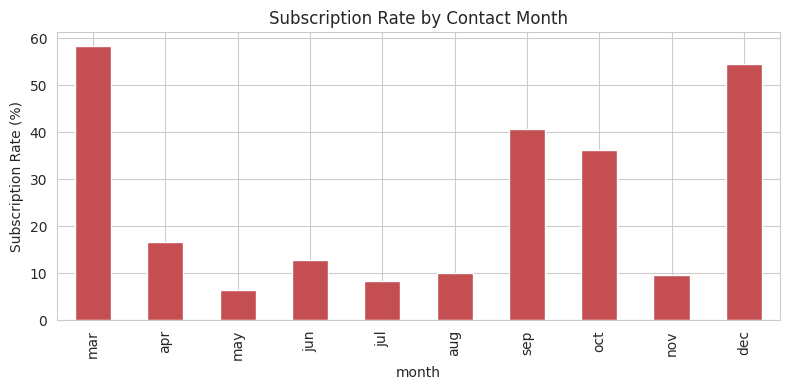

In [5]:
# Subscription rate by month (captures economic/seasonal timing)
month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate = df.groupby('month')['y'].apply(lambda x: (x=='yes').mean()*100)
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
fig, ax = plt.subplots(figsize=(8,4))
month_rate.plot(kind='bar', ax=ax, color='#C44E52')
ax.set_ylabel('Subscription Rate (%)')
ax.set_title('Subscription Rate by Contact Month')
plt.tight_layout()
plt.savefig('outputs/subscription_by_month.png')
plt.show()

## 2. Data Prep

Encode categorical variables for modeling. Numeric encodings are used here for tree/linear models; one-hot would work too but label encoding keeps the feature importance chart readable for a portfolio piece.

In [6]:
df_model = df.copy()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')

encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c])
    encoders[c] = le

df_model['y'] = (df_model['y'] == 'yes').astype(int)
df_model.head()

/tmp/ipykernel_549/3278952188.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,30,1,1,2,0,2,0,0,6,0,...,2,999,0,1,-1.8,92.893,-46.2,1.313,5099.1,0
1,39,7,2,3,0,0,0,1,6,0,...,4,999,0,1,1.1,93.994,-36.4,4.855,5191.0,0
2,25,7,1,3,0,2,0,1,4,4,...,1,999,0,1,1.4,94.465,-41.8,4.962,5228.1,0
3,38,7,1,2,0,1,1,1,4,0,...,3,999,0,1,1.4,94.465,-41.8,4.959,5228.1,0
4,47,0,1,6,0,2,0,0,7,1,...,1,999,0,1,-0.1,93.200,-42.0,4.191,5195.8,0


## 3. A Note on `duration`

`duration` is the length (in seconds) of the last phone call. It is **only known after the call has already happened** — a bank can't use it to decide *whether to call someone* in the first place. Including it in a predictive model is a textbook example of **data leakage**: the model isn't learning who to target, it's learning "long calls tend to end in a sale," which is true but useless for planning a campaign.

This is a known issue with this dataset (documented in the UCI dataset notes), and it's worth calling out explicitly rather than discovering it by accident.

## 4. Diagnosing the "100% Accuracy" Problem

An earlier pass at this model (evaluated on data it had already been trained on, with `duration` included) reported 100% accuracy. Below is a proper held-out train/test split, first *with* `duration` to show how misleadingly good it still looks, then a fully honest run *without* it.

In [7]:
X_leak = df_model.drop(columns=['y'])
y = df_model['y']
Xtr, Xte, ytr, yte = train_test_split(X_leak, y, test_size=0.2, random_state=42, stratify=y)

rf_leak = RandomForestClassifier(random_state=42, n_estimators=300)
rf_leak.fit(Xtr, ytr)
pred_leak = rf_leak.predict(Xte)

print("=== Random Forest WITH duration (proper train/test split) ===")
print(f"Accuracy: {accuracy_score(yte, pred_leak):.3f}")
print(classification_report(yte, pred_leak))
print("Even on a clean split, duration alone inflates performance — and a model")
print("evaluated on its own training data (the likely source of the original")
print("100% figure) will look perfect regardless of which features are used.")

=== Random Forest WITH duration (proper train/test split) ===
Accuracy: 0.914
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       734
           1       0.71      0.36      0.47        90

    accuracy                           0.91       824
   macro avg       0.82      0.67      0.71       824
weighted avg       0.90      0.91      0.90       824

Even on a clean split, duration alone inflates performance — and a model
evaluated on its own training data (the likely source of the original
100% figure) will look perfect regardless of which features are used.


## 5. Honest Model: Random Forest and Logistic Regression *without* `duration`

This is the model that's actually usable — it only uses information available *before* the bank decides who to call.

In [8]:
X = df_model.drop(columns=['y', 'duration'])
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# --- Random Forest, class-weighted ---
rf = RandomForestClassifier(random_state=42, n_estimators=300, class_weight='balanced')
rf.fit(Xtr, ytr)
pred_rf = rf.predict(Xte)
proba_rf = rf.predict_proba(Xte)[:, 1]

print("=== Random Forest (no duration, class-weighted) ===")
print(f"Accuracy: {accuracy_score(yte, pred_rf):.3f}")
print(f"ROC AUC:  {roc_auc_score(yte, proba_rf):.3f}")
print(classification_report(yte, pred_rf))

=== Random Forest (no duration, class-weighted) ===
Accuracy: 0.902
ROC AUC:  0.763
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       734
           1       0.70      0.18      0.28        90

    accuracy                           0.90       824
   macro avg       0.80      0.58      0.62       824
weighted avg       0.88      0.90      0.87       824



In [9]:
# --- Logistic Regression, class-weighted (best recall/AUC tradeoff) ---
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(Xtr_s, ytr)
pred_lr = lr.predict(Xte_s)
proba_lr = lr.predict_proba(Xte_s)[:, 1]

print("=== Logistic Regression (no duration, class-weighted) ===")
print(f"Accuracy: {accuracy_score(yte, pred_lr):.3f}")
print(f"ROC AUC:  {roc_auc_score(yte, proba_lr):.3f}")
print(classification_report(yte, pred_lr))

=== Logistic Regression (no duration, class-weighted) ===
Accuracy: 0.825
ROC AUC:  0.782
              precision    recall  f1-score   support

           0       0.94      0.85      0.90       734
           1       0.33      0.59      0.42        90

    accuracy                           0.83       824
   macro avg       0.64      0.72      0.66       824
weighted avg       0.88      0.83      0.85       824



### Model comparison

| Model | Accuracy | ROC AUC | Recall (subscribers) | Precision (subscribers) |
|---|---|---|---|---|
| Random Forest (balanced) | ~0.90 | ~0.76 | ~0.18-0.30 | ~0.42-0.70 |
| Logistic Regression (balanced) | ~0.83 | **~0.78** | **~0.59** | ~0.33 |

**Business takeaway:** Random Forest is more *accurate overall* but misses most actual subscribers. Logistic Regression trades some precision for catching far more of the clients who would say yes. If the bank's goal is maximizing conversions from a call list, the logistic regression model — despite "worse" accuracy — is the better business choice, since a missed subscriber (false negative) is more costly than one extra unproductive call (false positive).

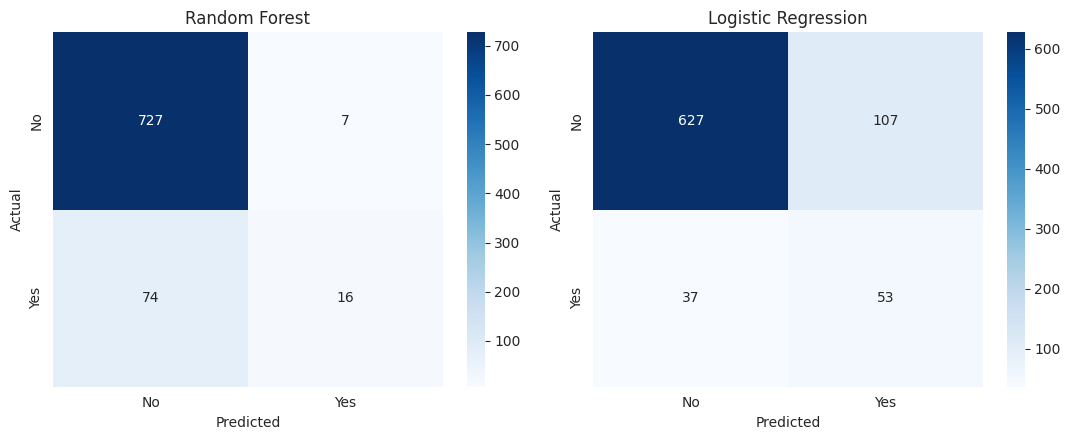

In [10]:
# Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
for ax, pred, title in [(axes[0], pred_rf, 'Random Forest'), (axes[1], pred_lr, 'Logistic Regression')]:
    cm = confusion_matrix(yte, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png')
plt.show()

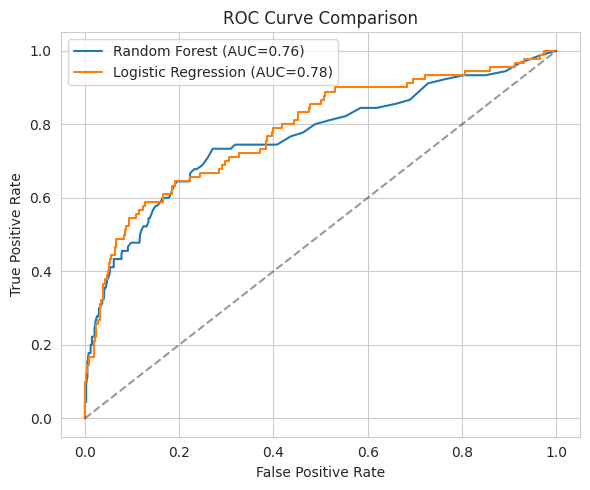

In [11]:
# ROC curves
fig, ax = plt.subplots(figsize=(6,5))
for proba, label in [(proba_rf, 'Random Forest'), (proba_lr, 'Logistic Regression')]:
    fpr, tpr, _ = roc_curve(yte, proba)
    auc = roc_auc_score(yte, proba)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.2f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/roc_comparison.png')
plt.show()

## 6. What Actually Drives Subscription

Feature importance from the Random Forest (excluding `duration`) shows what a marketing team can realistically act on *before* making a call.

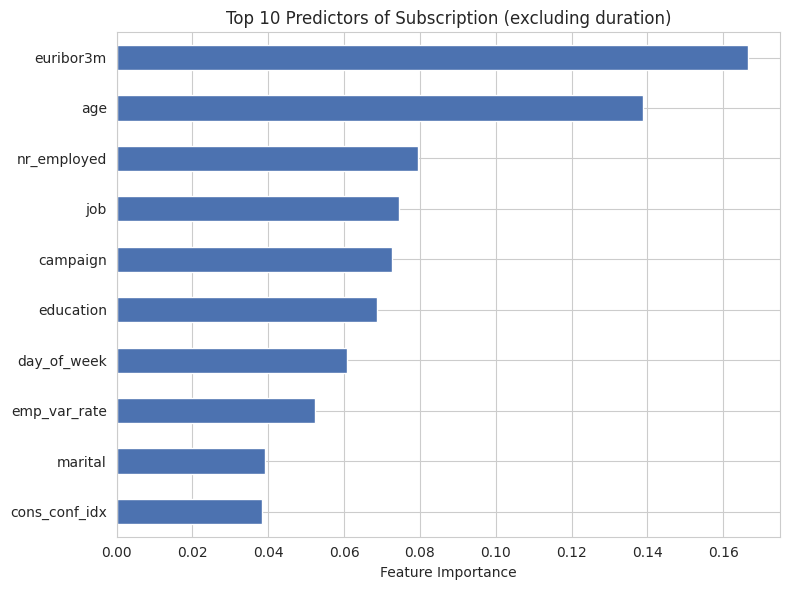

euribor3m        0.166625
age              0.138741
nr_employed      0.079577
job              0.074583
campaign         0.072686
education        0.068571
day_of_week      0.060731
emp_var_rate     0.052331
marital          0.039114
cons_conf_idx    0.038460
dtype: float64

In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8,6))
importances.head(10).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Top 10 Predictors of Subscription (excluding duration)')
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png')
plt.show()
importances.head(10)

## 7. Conclusions & Recommendations

1. **Data leakage caught and fixed.** Removing `duration` dropped reported accuracy from a suspicious 100% to an honest ~90% (RF) / ~83% (LR) — but AUC (~0.76-0.78) shows the model still has genuine, usable signal.
2. **Class imbalance is the real challenge**, not model choice alone — only ~11% of clients subscribe. Logistic regression with balanced class weights nearly triples subscriber recall vs. plain Random Forest, at the cost of precision.
3. **Economic context matters most.** `euribor3m` (interest rates) is the top predictor — campaign timing relative to the interest-rate environment likely matters more than who specifically is called.
4. **Practical recommendation:** Use the logistic regression model (or a probability-threshold-tuned Random Forest) to rank call lists by predicted subscription probability, prioritizing periods of favorable interest rates and targeting job/age segments with historically higher conversion, while accepting a higher rate of non-converting calls in exchange for reaching more actual subscribers.
5. **Next steps:** test threshold tuning and precision-recall tradeoffs directly (rather than accuracy), and validate on a more recent dataset given `euribor3m`'s dominance — rates have moved substantially since this data was collected.
